# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [4]:
import pandas as pd
import numpy as np
from Bio import SeqIO
import matplotlib.pyplot as plt

In [5]:
arquivos = ["srs12b.fasta", "sag1.fasta", "tuba1.fasta", "gra1.fasta", "sag3.fasta"]
dados = []
for arquivo in arquivos:
    gene = arquivo.replace(".fasta", "")
    for registro in SeqIO.parse(arquivo, "fasta"):
        dados.append({"sigla": gene, "codigo_referencia": registro.id, "sequencia_aa": str(registro.seq)})
df_fasta = pd.DataFrame(dados)
df_fasta = df_fasta.set_index("sigla")
df_fasta

,codigo_referencia,sequencia_aa
sigla,,
srs12b,XP_002371689.1,MARTGKVQQRRGGLRSGARKLVAVCLSGVVLLSGGSVVATEPVEGL...
sag1,AAO61460.1,MFPKAVRRAVTAGVFAAPTLMSFLLCGVMASDPPLVANQVVTCPDK...
tuba1,XP_002364807.1,MREVISIHVGQAGIQIGNACWELFCLEHGIQPDGQMPSDKTIGGGD...
gra1,XP_002365701.1,MVRVSAIVGAAASVFVCLSAGAYAAEGGDNQSSAVSDRASLLGLLS...
sag3,AAO72428.1,MQLWRRRAAGPASLGRQSLPLGCFFAAFGLCVLSAILGTGEHGLFV...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [6]:
aminoacidos = ["A", "R", "N", "D", "C", "Q", "E", "G", "H", "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]
df_aa = pd.DataFrame(columns=aminoacidos, index=df_fasta.index)
for gene in df_fasta.index:
    seq = df_fasta.loc[gene, "sequencia_aa"]
    contagem = []
    for aa in aminoacidos:
        contagem.append(seq.count(aa))
    df_aa.loc[gene] = contagem
df_aa

,A,R,N,D,C,Q,E,G,H,I,L,K,M,F,P,S,T,W,Y,V
sigla,,,,,,,,,,,,,,,,,,,,
srs12b,31,16,18,24,13,11,22,27,2,11,28,22,3,8,20,48,43,3,3,33
sag1,37,5,10,12,14,8,13,24,4,14,21,21,6,10,21,30,35,3,3,28
tuba1,36,21,18,27,13,12,36,38,13,25,35,19,14,20,19,27,25,4,17,34
gra1,18,7,8,14,1,11,21,19,0,9,16,7,7,4,2,16,8,0,3,19
sag3,24,18,14,15,14,11,24,46,9,11,31,21,4,16,29,29,20,7,15,27


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [7]:
valinas = df_aa["V"]
print("Valinas por gene:")
print(valinas)
print()
print(f"Gene com maior número: {valinas.idxmax()} - {valinas.max()} Valinas")

Valinas por gene:
sigla
srs12b    33
sag1      28
tuba1     34
gra1      19
sag3      27
Name: V, dtype: object

Gene com maior número: tuba1 - 34 Valinas


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [8]:
serinas = df_aa["S"]
media_serina = serinas.mean()
mediana_serina = serinas.median()
moda_serina = serinas.mode()[0]
print(f"Média de Serina: {media_serina}")
print(f"Mediana de Serina: {mediana_serina}")
print(f"Moda de Serina: {moda_serina}")

Média de Serina: 30.0
Mediana de Serina: 29.0
Moda de Serina: 16


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

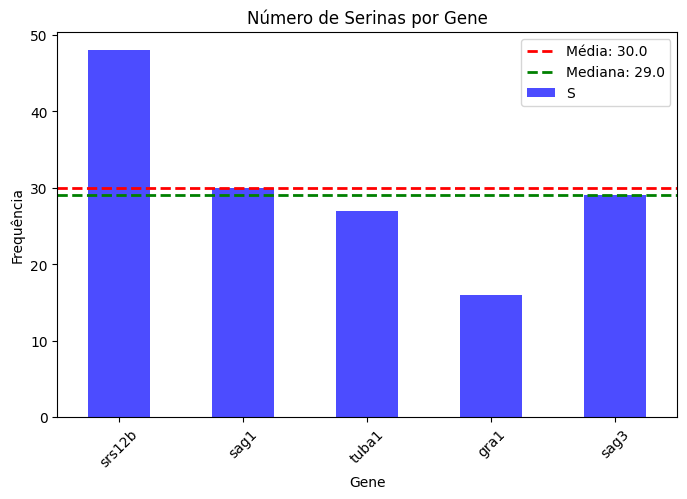

In [9]:
plt.figure(figsize=(8, 5))
serinas.plot(kind="bar", color="blue", alpha=0.7)
plt.axhline(media_serina, color="red", linestyle="--", linewidth=2, label=f"Média: {media_serina}")
plt.axhline(mediana_serina, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana_serina}")
plt.title("Número de Serinas por Gene")
plt.xlabel("Gene")
plt.ylabel("Frequência")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

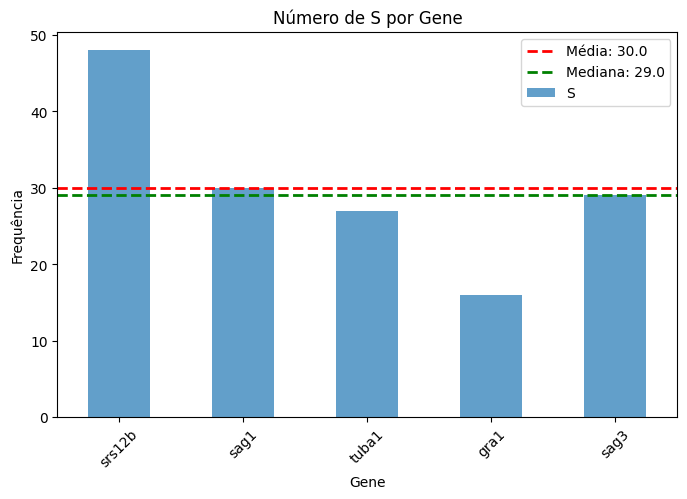

{'média': np.float64(30.0), 'mediana': np.float64(29.0), 'moda': 16}


In [10]:
def analiza_aa(df, aminoacido):
    dados = df[aminoacido]
    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()[0]
    plt.figure(figsize=(8, 5))
    dados.plot(kind="bar", alpha=0.7)
    plt.axhline(media, color="red", linestyle="--", linewidth=2, label=f"Média: {media}")
    plt.axhline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana}")
    plt.title(f"Número de {aminoacido} por Gene")
    plt.xlabel("Gene")
    plt.ylabel("Frequência")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()
    return {"média": media, "mediana": mediana, "moda": moda}
resultado = analiza_aa(df_aa, "S")
print(resultado)

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

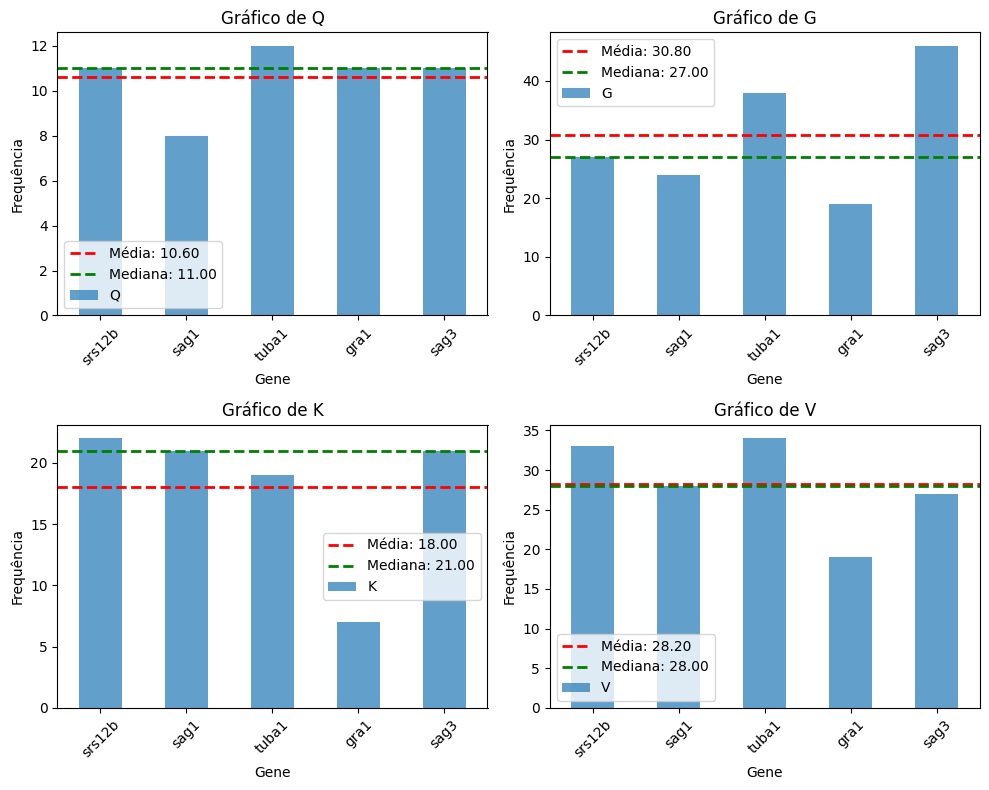

Diferenças entre média e mediana:
  Q: 0.40
  G: 3.80
  K: 3.00
  V: 0.20

Menor diferença: V


In [11]:
aa_selecionados = ["Q", "G", "K", "V"]
diferencas = {}
plt.figure(figsize=(10, 8))
for i, aa in enumerate(aa_selecionados):
    plt.subplot(2, 2, i + 1)
    df_aa[aa].plot(kind="bar", alpha=0.7)
    media = df_aa[aa].mean()
    mediana = df_aa[aa].median()
    diferenca = abs(media - mediana)
    diferencas[aa] = diferenca
    plt.axhline(media, color="red", linestyle="--", linewidth=2, label=f"Média: {media:.2f}")
    plt.axhline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.2f}")
    plt.title(f"Gráfico de {aa}")
    plt.xlabel("Gene")
    plt.ylabel("Frequência")
    plt.legend()
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Diferenças entre média e mediana:")
for aa, diff in diferencas.items():
    print(f"  {aa}: {diff:.2f}")
menor = min(diferencas, key=diferencas.get)
print(f"\nMenor diferença: {menor}")

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [12]:
tres_primeiros = df_aa.head(3)
cisteinas = tres_primeiros["C"]
media_cisteina = cisteinas.mean()
mediana_cisteina = cisteinas.median()
print(f"Média de Cisteína: {media_cisteina}")
print(f"Mediana de Cisteína: {mediana_cisteina}")

Média de Cisteína: 13.333333333333334
Mediana de Cisteína: 13.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [13]:
media_por_gene = df_aa.mean(axis=1)
print("Média por gene:")
print(media_por_gene)
print()
print(f"Maior gene: {media_por_gene.idxmax()}")

Média por gene:
sigla
srs12b     19.3
sag1      15.95
tuba1     22.65
gra1        9.5
sag3      19.25
dtype: object

Maior gene: tuba1


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [14]:
print(f"Menor gene: {media_por_gene.idxmin()}")

Menor gene: gra1
